# Seasonal Agriculture Performance Analysis
### VOIS AICTE Major Project — Batch 1 (2026-2027)

**Objective:** Analyze agricultural data across seasons (Kharif, Rabi, Zaid) to identify meaningful patterns, trends, relationships and differences in agricultural performance, and derive evidence-based, data-driven recommendations.

**Dataset:** `seasonal_agriculture_performance_dataset.csv`

---
**Notebook structure**
1. Import Libraries
2. Load Dataset
3. Data Exploration (initial understanding)
4. Data Cleaning & Preparation
5. Feature Engineering
6. Seasonal Performance Analysis (Univariate & Bivariate)
7. Relationships Between Environmental Conditions & Outcomes
8. Regional & Crop-wise Seasonal Comparison
9. Statistical Testing (ANOVA / significance of seasonal differences)
10. Outlier / Unusual Pattern Detection
11. Key Insights Summary
12. Conclusions & Recommendations


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display & plotting settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load Dataset

> Update the path below if your CSV is stored elsewhere.

In [2]:
DATA_PATH = "seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset shape: 4000 rows, 28 columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 3. Data Exploration

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF10001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,3952.0,NaN,NaN,NaN,601.152657,288.925025,80.0,370.2,582.0,834.95,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


In [5]:
print("Missing values per column:")
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique Seasons:", df['Season'].unique())
print("Unique Crops:", df['Crop'].unique())
print("Unique States:", df['State'].unique())
print("Unique Irrigation Methods:", df['Irrigation_Method'].unique())


Missing values per column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Duplicate rows: 0

Unique Seasons: <StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str
Unique Crops: <StringArray>
['Wheat', 'Maize', 'Pulses', 'Rice', 'Cotton', 'Chilli', 'Groundnut', 'Sugarcane']
Length: 8, dtype: str
Unique States: <StringArray>
['Andhra Pradesh', 'Maharashtra', 'Telangana', 'Karnataka', 'Gujarat', 'Tamil Nadu', 'Punjab', 'Madhya Pradesh']
Length: 8, dtype: str
Unique Irrigation Methods: <StringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str


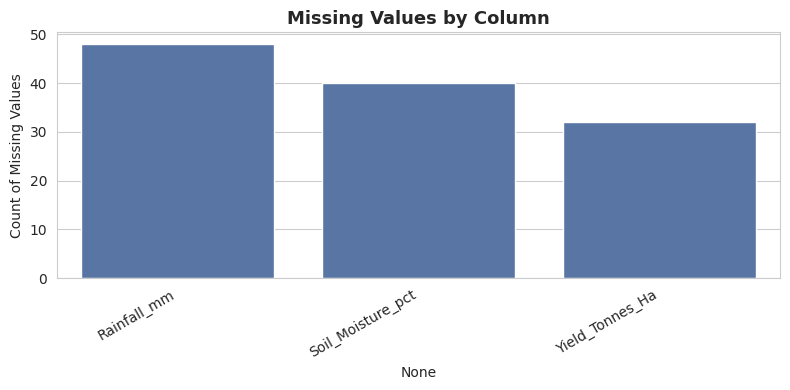

In [6]:
# Visualize missingness
plt.figure(figsize=(8,4))
sns.barplot(x=missing.index, y=missing.values, color='#4C72B0')
plt.title("Missing Values by Column")
plt.ylabel("Count of Missing Values")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 4. Data Cleaning & Preparation

**Columns with missing values:** `Rainfall_mm`, `Soil_Moisture_pct`, `Yield_Tonnes_Ha`.

Strategy:
- These are continuous numeric fields with a small proportion of missing values (~1%).
- We impute using the **median of the corresponding Season group**, since values are expected to vary meaningfully by season rather than globally.
- We also check for and cap extreme outliers using the IQR method (retained as a separate flag rather than deleted, so genuine seasonal extremes aren't lost).

In [7]:
df_clean = df.copy()

cols_to_impute = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

for col in cols_to_impute:
    df_clean[col] = df_clean.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print("Missing values after imputation:")
print(df_clean[cols_to_impute].isnull().sum())


Missing values after imputation:
Rainfall_mm          0
Soil_Moisture_pct    0
Yield_Tonnes_Ha      0
dtype: int64


In [8]:
# Standardize text columns
for col in ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Sanity checks: no negative values allowed for physically non-negative columns
non_negative_cols = ['Farm_Area_Hectares', 'Rainfall_mm', 'Fertilizer_kg_ha',
                      'Pesticide_Litre_ha', 'Yield_Tonnes_Ha', 'Production_Tonnes',
                      'Water_Used_m3']
for col in non_negative_cols:
    neg_count = (df_clean[col] < 0).sum()
    if neg_count > 0:
        print(f"Warning: {neg_count} negative values found in {col}")

print("Data cleaning complete. Shape:", df_clean.shape)


Data cleaning complete. Shape: (4000, 28)


## 5. Feature Engineering

Deriving a few helper metrics that make seasonal comparison easier:
- **Profit_Margin_pct** = Profit / Revenue
- **Cost_per_Hectare**
- **Yield_per_mm_Rainfall** (rough efficiency indicator)
- **Loss_Flag** — farms operating at a loss (Profit_INR < 0)

In [9]:
df_clean['Profit_Margin_pct'] = (df_clean['Profit_INR'] / df_clean['Revenue_INR'].replace(0, np.nan)) * 100
df_clean['Cost_per_Hectare'] = df_clean['Total_Cost_INR'] / df_clean['Farm_Area_Hectares']
df_clean['Yield_per_mm_Rainfall'] = df_clean['Yield_Tonnes_Ha'] / df_clean['Rainfall_mm'].replace(0, np.nan)
df_clean['Loss_Flag'] = df_clean['Profit_INR'] < 0

df_clean[['Profit_Margin_pct', 'Cost_per_Hectare', 'Yield_per_mm_Rainfall', 'Loss_Flag']].describe(include='all')


,Profit_Margin_pct,Cost_per_Hectare,Yield_per_mm_Rainfall,Loss_Flag
count,4000.000000,4000.000000,4000.000000,4000
unique,NaN,NaN,NaN,2
top,NaN,NaN,NaN,False
freq,NaN,NaN,NaN,2034
mean,-45.492178,66660.084938,0.011792,NaN
std,158.085472,8845.644258,0.036350,NaN
min,-1461.851219,35807.382550,0.000227,NaN
25%,-60.192762,60597.205943,0.001800,NaN
50%,1.146236,66614.048166,0.003278,NaN
75%,32.885876,72739.977527,0.005747,NaN


## 6. Seasonal Performance Analysis

### 6.1 Overview: Key metrics by season

In [10]:
key_metrics = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Revenue_INR', 'Total_Cost_INR',
               'Profit_INR', 'Profit_Margin_pct', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3',
               'Disease_Pest_Risk_pct']

season_summary = df_clean.groupby('Season')[key_metrics].mean().round(2)
season_summary


,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Profit_Margin_pct,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,,
Kharif,5.63,46.31,710719.06,531804.41,178914.65,-38.64,6102.20,5.89,54.47
Rabi,5.04,41.49,601526.05,513836.58,87689.47,-44.27,5846.99,5.19,40.48
Zaid,4.64,38.89,519171.90,543976.73,-24804.82,-69.35,6419.89,4.41,38.22


/tmp/ipykernel_523/2650344828.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y='Yield_Tonnes_Ha', estimator=np.mean,
/tmp/ipykernel_523/2650344828.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y='Profit_INR', estimator=np.mean,


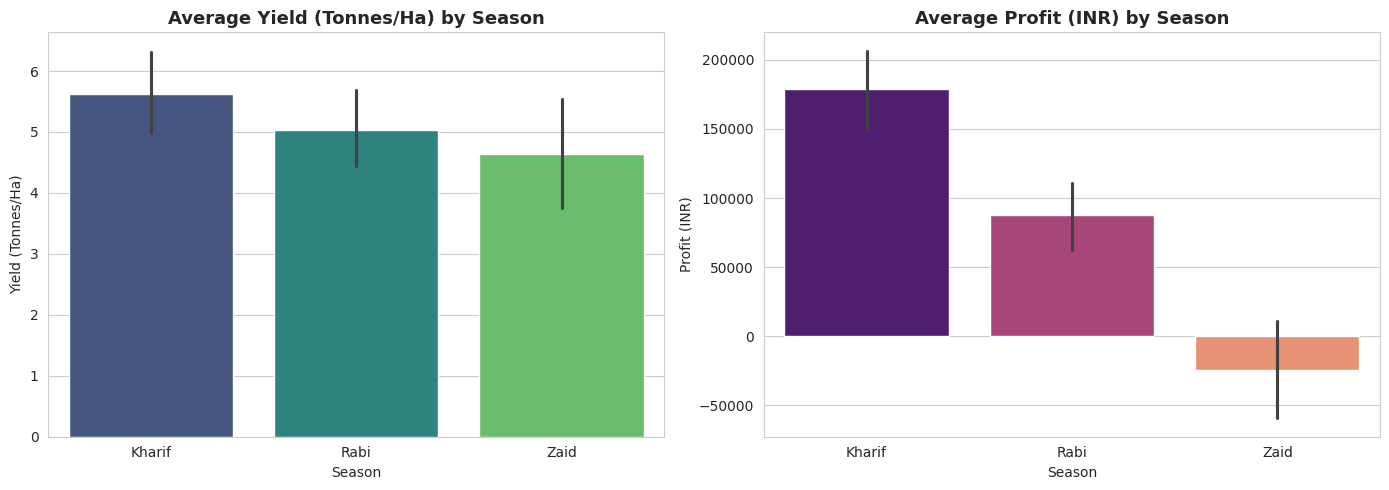

In [11]:
# Visual: Average Yield & Profit by Season
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_clean, x='Season', y='Yield_Tonnes_Ha', estimator=np.mean,
            order=['Kharif', 'Rabi', 'Zaid'], palette='viridis', ax=axes[0])
axes[0].set_title("Average Yield (Tonnes/Ha) by Season")
axes[0].set_ylabel("Yield (Tonnes/Ha)")

sns.barplot(data=df_clean, x='Season', y='Profit_INR', estimator=np.mean,
            order=['Kharif', 'Rabi', 'Zaid'], palette='magma', ax=axes[1])
axes[1].set_title("Average Profit (INR) by Season")
axes[1].set_ylabel("Profit (INR)")

plt.tight_layout()
plt.show()


/tmp/ipykernel_523/3135398134.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y='Profit_INR', order=['Kharif', 'Rabi', 'Zaid'], palette='Set2')


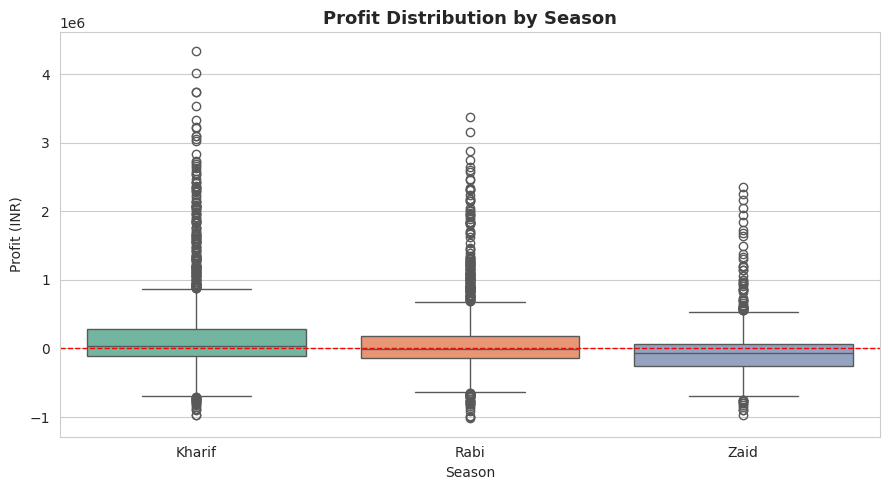

In [12]:
# Distribution of Profit by Season (boxplot to see spread & outliers)
plt.figure(figsize=(9,5))
sns.boxplot(data=df_clean, x='Season', y='Profit_INR', order=['Kharif', 'Rabi', 'Zaid'], palette='Set2')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Profit Distribution by Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()


### 6.2 Environmental conditions by season

/tmp/ipykernel_523/3068770078.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y=col, order=['Kharif', 'Rabi', 'Zaid'],


/tmp/ipykernel_523/3068770078.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y=col, order=['Kharif', 'Rabi', 'Zaid'],
/tmp/ipykernel_523/3068770078.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y=col, order=['Kharif', 'Rabi', 'Zaid'],
/tmp/ipykernel_523/3068770078.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y=col, order=['Kharif', 'Rabi', 'Zaid'],
/tmp/ipykernel_523/3068770078.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is

/tmp/ipykernel_523/3068770078.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y=col, order=['Kharif', 'Rabi', 'Zaid'],


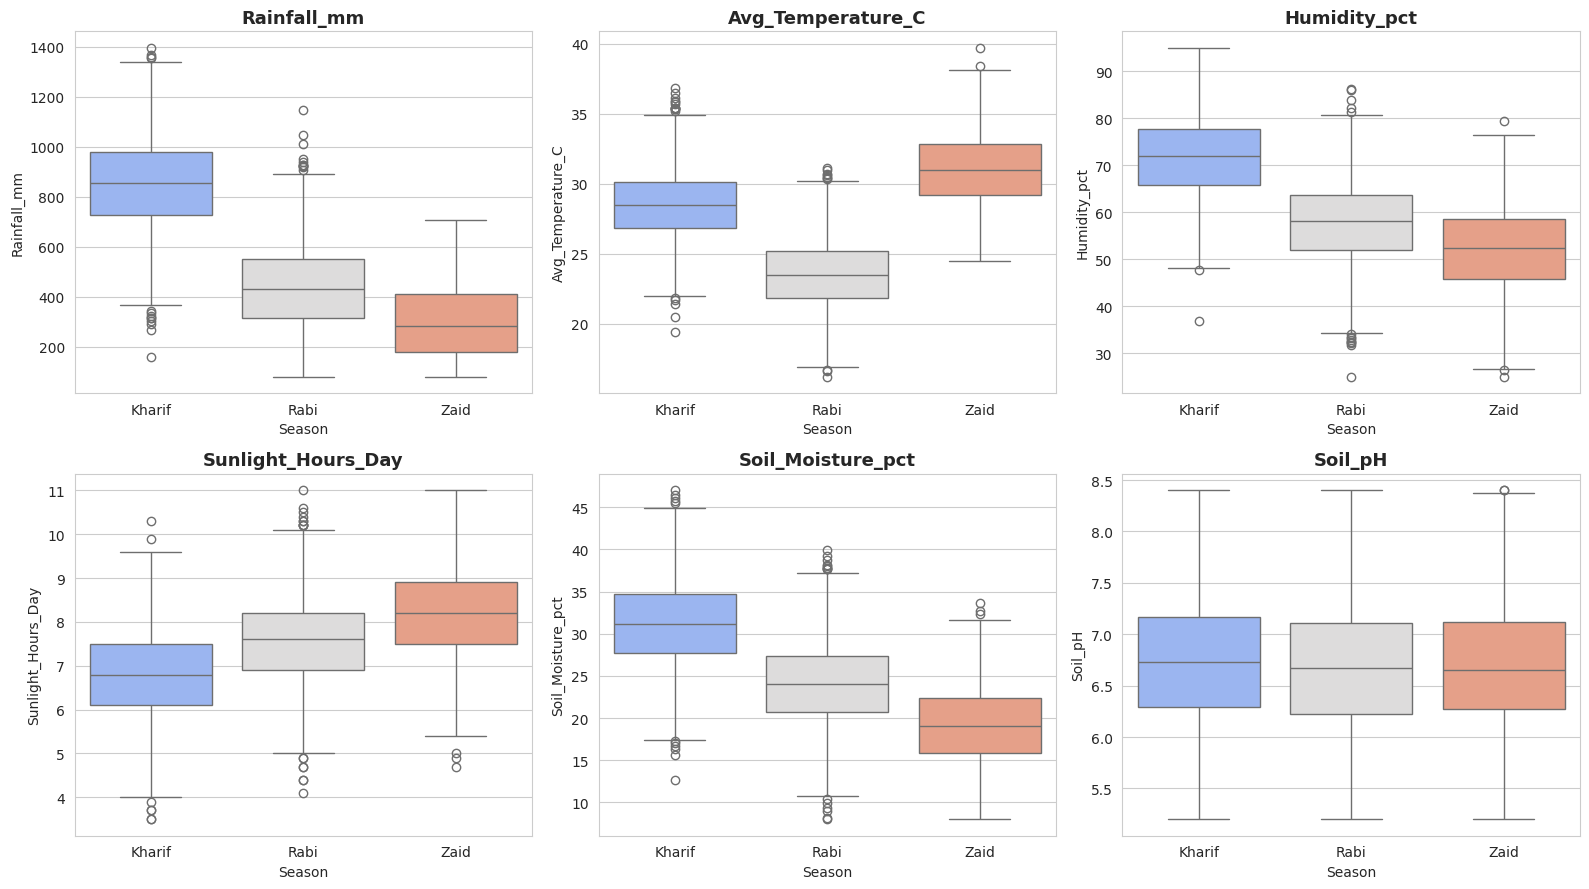

In [13]:
env_metrics = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day',
               'Soil_Moisture_pct', 'Soil_pH']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(env_metrics):
    sns.boxplot(data=df_clean, x='Season', y=col, order=['Kharif', 'Rabi', 'Zaid'],
                palette='coolwarm', ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


### 6.3 Resource usage by season (Fertilizer, Pesticide, Water)

/tmp/ipykernel_523/2751866946.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y=col, estimator=np.mean,
/tmp/ipykernel_523/2751866946.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y=col, estimator=np.mean,
/tmp/ipykernel_523/2751866946.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y=col, estimator=np.mean,


/tmp/ipykernel_523/2751866946.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y=col, estimator=np.mean,


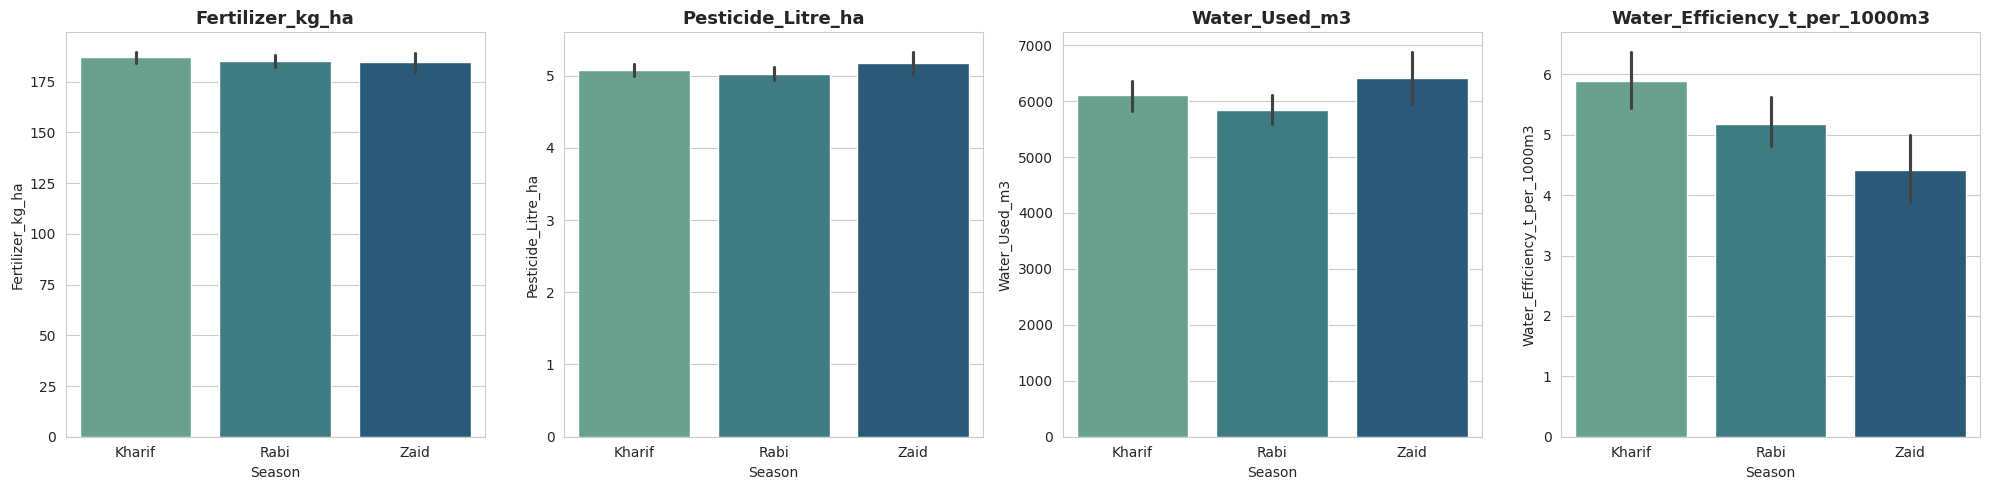

In [14]:
resource_metrics = ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(resource_metrics):
    sns.barplot(data=df_clean, x='Season', y=col, estimator=np.mean,
                order=['Kharif', 'Rabi', 'Zaid'], palette='crest', ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


## 7. Relationships Between Environmental Conditions & Agricultural Outcomes

### 7.1 Correlation heatmap (numeric features)

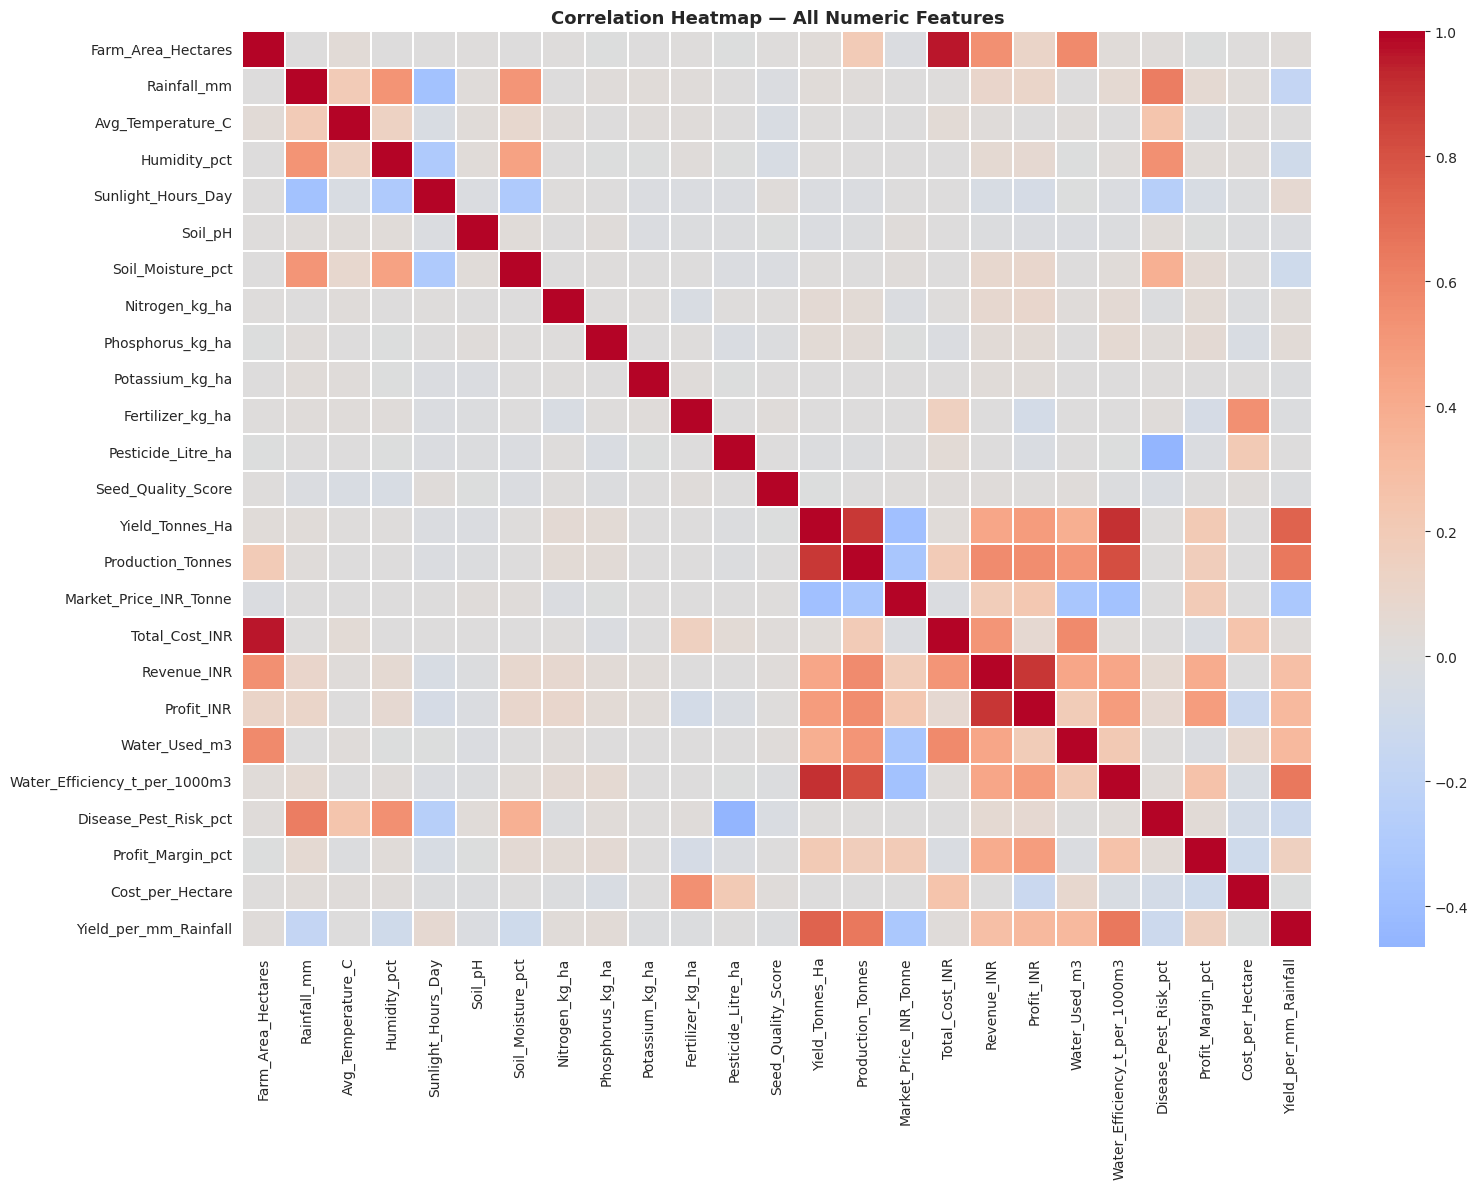

In [15]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title("Correlation Heatmap — All Numeric Features")
plt.tight_layout()
plt.show()


In [16]:
# Focused correlation: what drives Yield and Profit?
target_corr = corr[['Yield_Tonnes_Ha', 'Profit_INR']].sort_values('Profit_INR', ascending=False)
target_corr


,Yield_Tonnes_Ha,Profit_INR
Profit_INR,0.488459,1.000000
Revenue_INR,0.432139,0.887331
Production_Tonnes,0.882804,0.554172
Water_Efficiency_t_per_1000m3,0.912561,0.489487
Yield_Tonnes_Ha,1.000000,0.488459
Profit_Margin_pct,0.205021,0.481375
Yield_per_mm_Rainfall,0.736965,0.323213
Market_Price_INR_Tonne,-0.382627,0.225119
Water_Used_m3,0.386298,0.190278
Farm_Area_Hectares,0.030194,0.115241


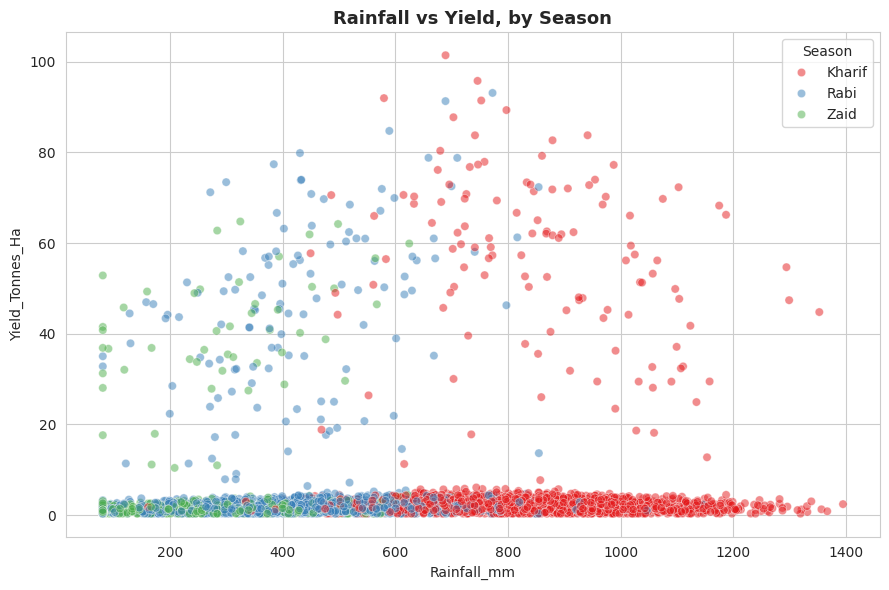

In [17]:
# Scatter: Rainfall vs Yield, colored by Season
plt.figure(figsize=(9,6))
sns.scatterplot(data=df_clean, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season',
                 palette='Set1', alpha=0.5)
plt.title("Rainfall vs Yield, by Season")
plt.tight_layout()
plt.show()


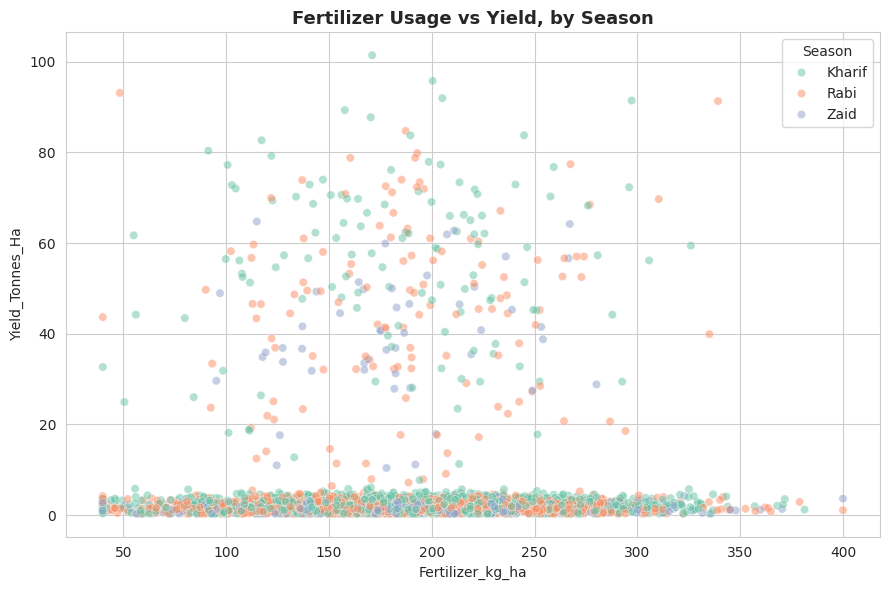

In [18]:
# Scatter: Fertilizer usage vs Yield
plt.figure(figsize=(9,6))
sns.scatterplot(data=df_clean, x='Fertilizer_kg_ha', y='Yield_Tonnes_Ha', hue='Season',
                 palette='Set2', alpha=0.5)
plt.title("Fertilizer Usage vs Yield, by Season")
plt.tight_layout()
plt.show()


## 8. Regional & Crop-wise Seasonal Comparison

### 8.1 Average profit by Crop and Season (heatmap)

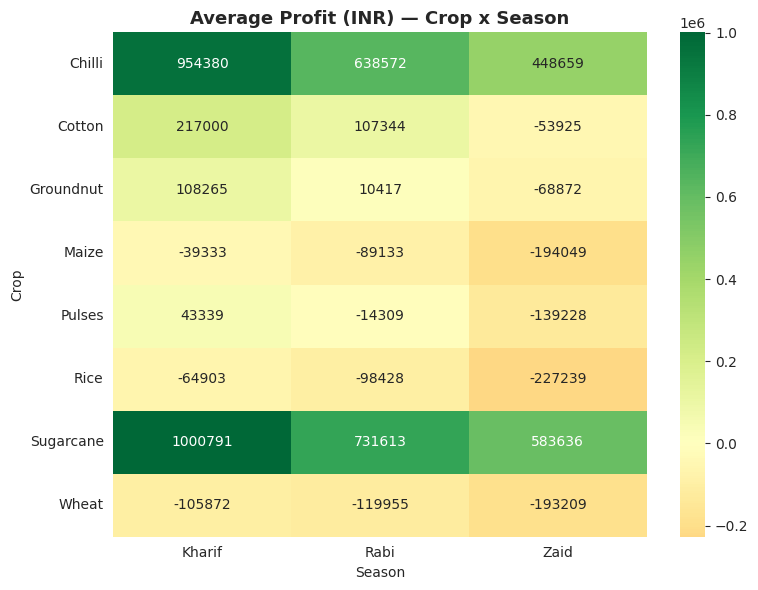

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.0,638572.0,448659.0
Cotton,217000.0,107344.0,-53925.0
Groundnut,108265.0,10417.0,-68872.0
Maize,-39333.0,-89133.0,-194049.0
Pulses,43339.0,-14309.0,-139228.0
Rice,-64903.0,-98428.0,-227239.0
Sugarcane,1000791.0,731613.0,583636.0
Wheat,-105872.0,-119955.0,-193209.0


In [19]:
pivot_profit = df_clean.pivot_table(values='Profit_INR', index='Crop', columns='Season',
                                      aggfunc='mean').round(0)
pivot_profit = pivot_profit[['Kharif', 'Rabi', 'Zaid']]

plt.figure(figsize=(8,6))
sns.heatmap(pivot_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title("Average Profit (INR) — Crop x Season")
plt.tight_layout()
plt.show()
pivot_profit


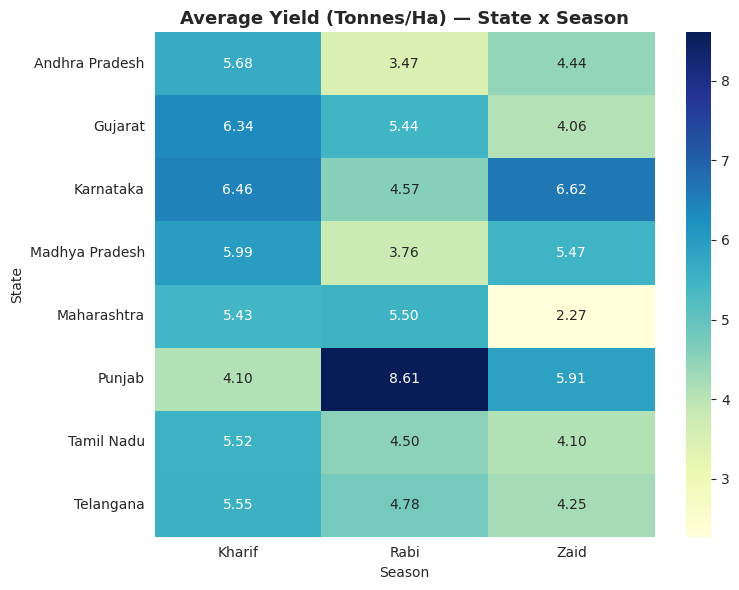

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.68,3.47,4.44
Gujarat,6.34,5.44,4.06
Karnataka,6.46,4.57,6.62
Madhya Pradesh,5.99,3.76,5.47
Maharashtra,5.43,5.50,2.27
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.50,4.10
Telangana,5.55,4.78,4.25


In [20]:
# Average yield by State and Season
pivot_yield = df_clean.pivot_table(values='Yield_Tonnes_Ha', index='State', columns='Season',
                                     aggfunc='mean').round(2)
pivot_yield = pivot_yield[['Kharif', 'Rabi', 'Zaid']]

plt.figure(figsize=(8,6))
sns.heatmap(pivot_yield, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title("Average Yield (Tonnes/Ha) — State x Season")
plt.tight_layout()
plt.show()
pivot_yield


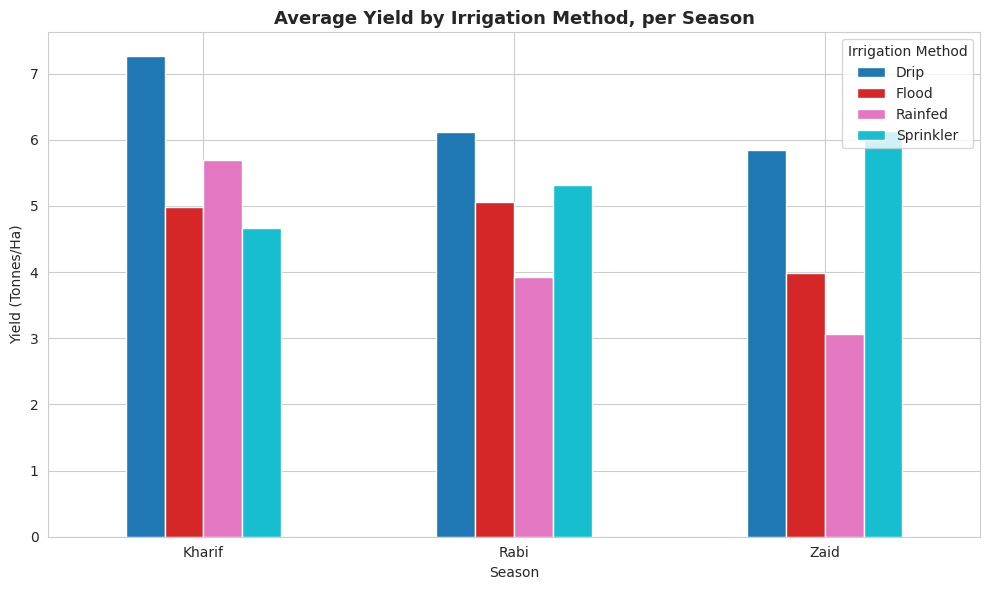

In [21]:
# Irrigation method effectiveness by season
irrigation_summary = df_clean.groupby(['Season', 'Irrigation_Method'])['Yield_Tonnes_Ha'].mean().unstack().round(2)
irrigation_summary = irrigation_summary.loc[['Kharif', 'Rabi', 'Zaid']]

irrigation_summary.plot(kind='bar', figsize=(10,6), colormap='tab10')
plt.title("Average Yield by Irrigation Method, per Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.legend(title='Irrigation Method')
plt.tight_layout()
plt.show()


## 9. Statistical Testing — Are Seasonal Differences Significant?

We use a **one-way ANOVA** to test whether the mean Yield and mean Profit differ significantly across the three seasons (H0: means are equal across seasons).

In [22]:
def run_anova(df, value_col, group_col='Season'):
    groups = [g[value_col].dropna().values for _, g in df.groupby(group_col)]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"ANOVA for '{value_col}' across '{group_col}':")
    print(f"  F-statistic = {f_stat:.3f}, p-value = {p_val:.5f}")
    if p_val < 0.05:
        print("  -> Statistically significant difference across seasons (p < 0.05)")
    else:
        print("  -> No statistically significant difference across seasons (p >= 0.05)")
    print()
    return f_stat, p_val

for metric in ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Used_m3', 'Disease_Pest_Risk_pct']:
    run_anova(df_clean, metric)


ANOVA for 'Yield_Tonnes_Ha' across 'Season':
  F-statistic = 1.554, p-value = 0.21156
  -> No statistically significant difference across seasons (p >= 0.05)

ANOVA for 'Profit_INR' across 'Season':
  F-statistic = 34.292, p-value = 0.00000
  -> Statistically significant difference across seasons (p < 0.05)

ANOVA for 'Water_Used_m3' across 'Season':
  F-statistic = 2.467, p-value = 0.08501
  -> No statistically significant difference across seasons (p >= 0.05)

ANOVA for 'Disease_Pest_Risk_pct' across 'Season':
  F-statistic = 1049.467, p-value = 0.00000
  -> Statistically significant difference across seasons (p < 0.05)



## 10. Outlier / Unusual Pattern Detection

Using the IQR method to flag farms with unusually high losses or unusually high yields per season.

In [23]:
def flag_outliers_iqr(df, col, group_col='Season'):
    def _flag(group):
        q1, q3 = group[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
        return (group[col] < lower) | (group[col] > upper)
    return df.groupby(group_col, group_keys=False).apply(_flag)

df_clean['Profit_Outlier'] = flag_outliers_iqr(df_clean, 'Profit_INR')
outlier_counts = df_clean.groupby('Season')['Profit_Outlier'].sum()
print("Profit outliers per season:")
print(outlier_counts)

loss_rate = df_clean.groupby('Season')['Loss_Flag'].mean().mul(100).round(1)
print("\n% of farms operating at a loss, by season:")
print(loss_rate)


Profit outliers per season:
Season
Kharif    184
Rabi      174
Zaid       64
Name: Profit_Outlier, dtype: int64

% of farms operating at a loss, by season:
Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
Name: Loss_Flag, dtype: float64


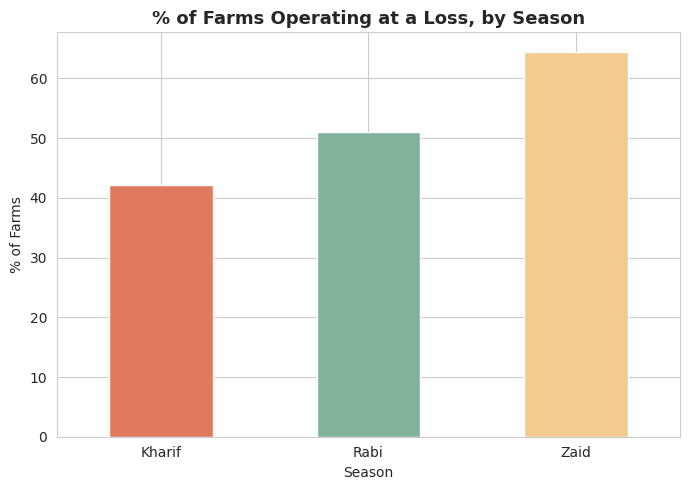

In [24]:
plt.figure(figsize=(7,5))
loss_rate.reindex(['Kharif','Rabi','Zaid']).plot(kind='bar', color=['#e07a5f','#81b29a','#f2cc8f'])
plt.title("% of Farms Operating at a Loss, by Season")
plt.ylabel("% of Farms")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 11. Key Insights Summary

*(Run the cells above first — the printed values below reference the computed results.)*

In [25]:
print("SEASONAL SUMMARY (mean values):\n")
print(season_summary)

best_yield_season = season_summary['Yield_Tonnes_Ha'].idxmax()
best_profit_season = season_summary['Profit_INR'].idxmax()
worst_profit_season = season_summary['Profit_INR'].idxmin()
highest_water_season = season_summary['Water_Used_m3'].idxmax()
highest_risk_season = season_summary['Disease_Pest_Risk_pct'].idxmax()

print(f"\nSeason with highest average yield: {best_yield_season}")
print(f"Season with highest average profit: {best_profit_season}")
print(f"Season with lowest average profit: {worst_profit_season}")
print(f"Season with highest average water usage: {highest_water_season}")
print(f"Season with highest disease/pest risk: {highest_risk_season}")


SEASONAL SUMMARY (mean values):

        Yield_Tonnes_Ha  Production_Tonnes  Revenue_INR  Total_Cost_INR  Profit_INR  Profit_Margin_pct  Water_Used_m3  \
Season                                                                                                                  
Kharif             5.63              46.31    710719.06       531804.41   178914.65             -38.64        6102.20   
Rabi               5.04              41.49    601526.05       513836.58    87689.47             -44.27        5846.99   
Zaid               4.64              38.89    519171.90       543976.73   -24804.82             -69.35        6419.89   

        Water_Efficiency_t_per_1000m3  Disease_Pest_Risk_pct  
Season                                                        
Kharif                           5.89                  54.47  
Rabi                             5.19                  40.48  
Zaid                             4.41                  38.22  

Season with highest average yield: Kharif
Sea

## 12. Conclusions & Recommendations

**Fill this section in after reviewing your actual output above** — the structure below is a guide.

### Conclusions
- Summarize which season shows the strongest overall agricultural performance (yield + profit) and why (link to rainfall, temperature, resource use).
- Note whether seasonal differences in yield/profit are statistically significant (see ANOVA results in Section 9).
- Highlight which crops/states are most sensitive to seasonal change (Section 8).
- Mention resource-efficiency findings (fertilizer, water) — is higher input always translating into higher yield/profit?
- Note any seasons/crops with a high proportion of loss-making farms (Section 10) as areas of concern.

### Recommendations
- Suggest which irrigation methods appear most effective per season, based on Section 8.3.
- Recommend crop-season combinations that show consistently strong profitability.
- Flag seasons/regions that may benefit from targeted support (e.g., subsidized inputs, improved irrigation, pest management) based on high loss rates or high disease/pest risk.
- Suggest further analysis (e.g., regression modeling of yield/profit drivers, time-series analysis if multi-year data becomes available).
